### Fourth-Order Runge-Kutta method (KE4) and First-Order Forward Euler Method Comparisons for TRAPPIST-1e

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
from rungekuttaandforwardruler import RungeKutta4, euler_step

In [15]:
# constants
G = 6.67430e-11
M = 0.0898 * 1.989e30

# TRAPPIST-1e initial position conditions
x0 = 0.02925 * 1.496e11   # semi-major axis: AU -> meters
y0 = 0.0 # chosen

vx0 = 0.0
vy0 = np.sqrt(G * M / x0)

### FE Trajectory

In [16]:
# initial state for the first order forward ruler orbit
state = np.array([x0, y0, vx0, vy0], dtype=float)

# orbital period
orbital_period = 2 * np.pi * np.sqrt(x0**3 / (G * M))

# integration setup
dt = 1000 # step size in seconds
T_total = 10 * orbital_period
N_steps = int(T_total / dt)

In [17]:
# FE integration
trajectory_euler = []

state_euler = np.array([x0, y0, vx0, vy0], dtype=float)
t = 0.0

for i in range(N_steps):
    trajectory_euler.append(state_euler.copy())
    state_euler = euler_step(RungeKutta4.orbit_rhs, t, state_euler, dt)
    t += dt

trajectory_euler = np.array(trajectory_euler)

### RK4 Trajectory

In [6]:
# RK4 integration
trajectory_rk4 = []

state_rk4 = np.array([x0, y0, vx0, vy0], dtype=float)
t = 0.0

for i in range(N_steps):
    trajectory_rk4.append(state_rk4.copy())
    state_rk4 = RungeKutta4.step(RungeKutta4.orbit_rhs, t, state_rk4, dt)
    t += dt

trajectory_rk4 = np.array(trajectory_rk4)

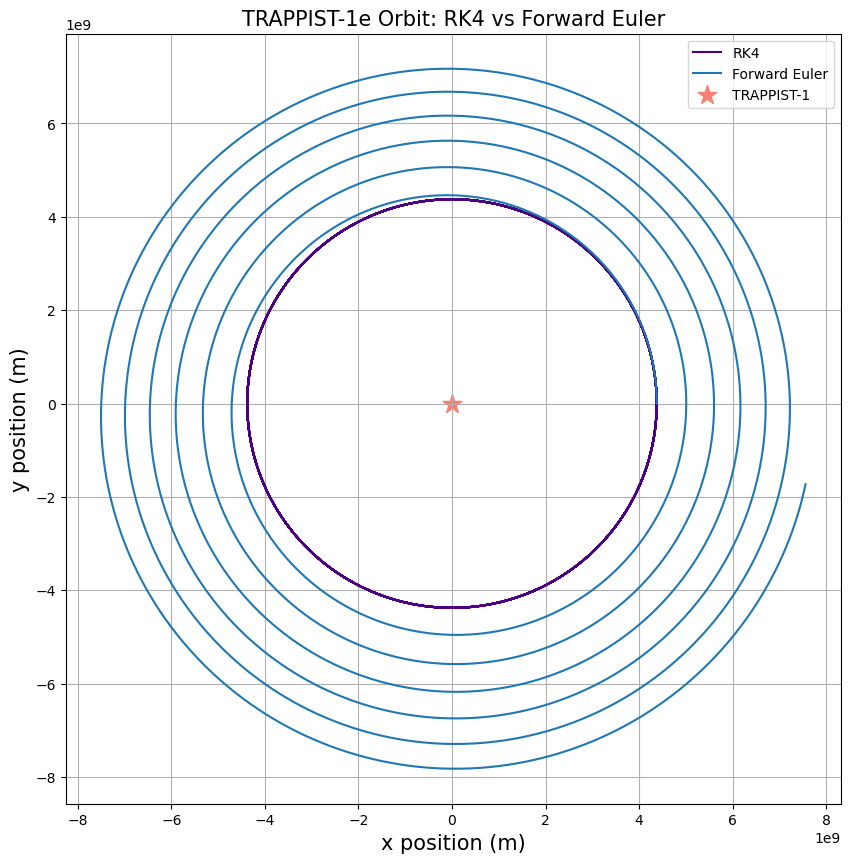

In [7]:
plt.figure(figsize=(10, 10))

plt.plot(trajectory_rk4[:, 0], trajectory_rk4[:, 1], label="RK4", color="indigo")
plt.plot(trajectory_euler[:, 0], trajectory_euler[:, 1], label="Forward Euler")

plt.scatter(0, 0, marker="*", s=200, label="TRAPPIST-1", color="salmon")

plt.xlabel("x position (m)", fontsize=15)
plt.ylabel("y position (m)", fontsize=15)
plt.title("TRAPPIST-1e Orbit: RK4 vs Forward Euler", fontsize=15)
plt.axis("equal")

plt.grid()
plt.legend()
plt.savefig("trappist1eorbit.png", bbox_inches='tight')
plt.show()

### Analysis:

- RK4 maintains orbital stability over 10 orbits
- FE accumulates substantial numerical drift
- Higher-order integrators are essential for long-term orbital simulations

----

### Relative energy error for both methods

In [ ]:
# RK4 relative energy error
x_rk4 = trajectory_rk4[:, 0]
y_rk4 = trajectory_rk4[:, 1]
vx_rk4 = trajectory_rk4[:, 2]
vy_rk4 = trajectory_rk4[:, 3]

r_rk4 = np.sqrt(x_rk4**2 + y_rk4**2)

energy_rk4 = 0.5*(vx_rk4**2 + vy_rk4**2) - G*M/r_rk4

energy_error_rk4 = (
    (energy_rk4 - energy_rk4[0])
    / abs(energy_rk4[0])
)

# FE relative energy error
x_euler = trajectory_euler[:, 0]
y_euler = trajectory_euler[:, 1]
vx_euler = trajectory_euler[:, 2]
vy_euler = trajectory_euler[:, 3]

r_euler = np.sqrt(x_euler**2 + y_euler**2)

energy_euler = 0.5*(vx_euler**2 + vy_euler**2) - G*M/r_euler

energy_error_euler = (
    (energy_euler - energy_euler[0])
    / abs(energy_euler[0])
)

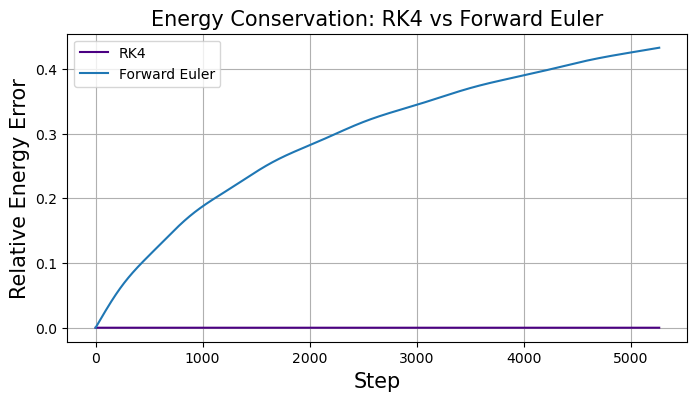

In [19]:
plt.figure(figsize=(8,4))

plt.plot(energy_error_rk4, label='RK4', color="indigo")
plt.plot(energy_error_euler, label='Forward Euler')

plt.xlabel("Step", fontsize=15)
plt.ylabel("Relative Energy Error", fontsize=15)
plt.title("Energy Conservation: RK4 vs Forward Euler", fontsize=15)

plt.grid()
plt.legend()
plt.savefig("energyconservation.png", bbox_inches='tight')
plt.show()

### Analysis:

RK4 (blue)

- Relative energy error remains extremely close to zero
- Indicates excellent energy conservation
- Numerical errors stay very small over 10 orbits

This explains why the RK4 orbit stayed nearly circular.

FE (orange)

- Energy error steadily increases over time
- By the end of the simulation:
$$\frac{\Delta E}{E_0} \approx 0.43$$

meaning the system gained roughly 43% artificial energy due purely to numerical error. That is enormous.

**Physical interpretation**

Because the Euler method artificially increases the orbital energy:

- the orbit expands outward
- the planet moves farther from the star
- the trajectory spirals instead of remaining closed

This directly matches the orbit plot.

The Forward Euler method exhibited significant numerical drift, causing the relative energy error to increase continuously throughout the simulation. This artificial increase in orbital energy caused the orbit to spiral outward over time. In contrast, the RK4 integrator maintained near-constant energy conservation, producing a stable closed orbit over ten orbital periods.

This connects directly to your M-dwarf irradiation discussion.

$$F \alpha \frac{1}{r^2}$$

the outward spiral from Euler would:

- artificially reduce stellar irradiation
- produce incorrect physical predictions

### Relative angular momentum error for both methods

In [20]:
# RK4 relative angular momentum error
x_rk4_m = trajectory_rk4[:, 0]
y_rk4_m = trajectory_rk4[:, 1]
vx_rk4_m = trajectory_rk4[:, 2]
vy_rk4_m = trajectory_rk4[:, 3]

L_rk4 = x_rk4_m * vy_rk4_m - y_rk4_m * vx_rk4_m

L_error_rk4 = (
    (L_rk4 - L_rk4[0])
    / abs(L_rk4[0])
)

# FE relative angular momentum error
x_euler_m = trajectory_euler[:, 0]
y_euler_m = trajectory_euler[:, 1]
vx_euler_m = trajectory_euler[:, 2]
vy_euler_m = trajectory_euler[:, 3]

L_euler = x_euler_m * vy_euler_m - y_euler_m * vx_euler_m

L_error_euler = (
    (L_euler - L_euler[0])
    / abs(L_euler[0])
)

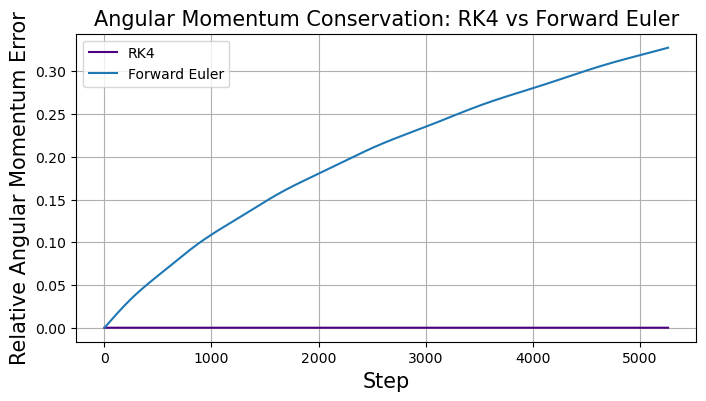

In [21]:
plt.figure(figsize=(8,4))

plt.plot(L_error_rk4, label='RK4', color="indigo")
plt.plot(L_error_euler, label='Forward Euler')

plt.xlabel("Step", fontsize=15)
plt.ylabel("Relative Angular Momentum Error", fontsize=15)
plt.title("Angular Momentum Conservation: RK4 vs Forward Euler", fontsize=15)

plt.grid()
plt.legend()
plt.savefig("angularmomentumconservation.png", bbox_inches='tight')
plt.show()

### Analysis:

RK4 (blue)

- Angular momentum error remains essentially zero
- Indicates excellent conservation of angular momentum
- Confirms the stability of the RK4 orbit over long integrations

FE (orange)

- Angular momentum error steadily increases throughout the simulation
- By the end of the simulation:
$$\frac{\Delta L}{L_0} \approx 0.33$$

meaning the Euler method introduced roughly a 33% artificial change in angular momentum.

This explains why:
- the orbit spiraled outward
- the orbital radius increased
- the trajectory became increasingly inaccurate

In a true two-body gravitational system:
- angular momentum should remain constant
- the orbit should remain closed

The Forward Euler method fails to conserve angular momentum because truncation errors accumulate at every timestep. These errors distort the orbital velocity and gradually alter the trajectory.

In contrast, RK4 maintains both energy and angular momentum conservation much more effectively, producing a physically stable orbit over ten orbital periods.

### Irradiation Comparison

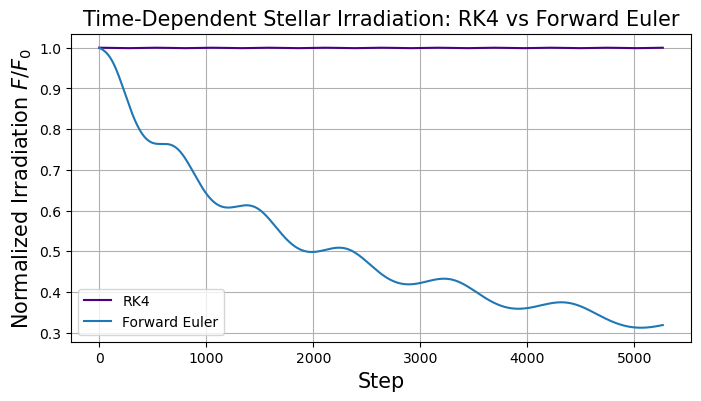

In [22]:
# Distance from star
r_rk4 = np.sqrt(x_rk4**2 + y_rk4**2)
r_euler = np.sqrt(x_euler**2 + y_euler**2)

# Normalized irradiation: F/F0 = (r0/r)^2
flux_rk4 = (r_rk4[0] / r_rk4)**2
flux_euler = (r_euler[0] / r_euler)**2

plt.figure(figsize=(8,4))

plt.plot(flux_rk4, label="RK4", color="indigo")
plt.plot(flux_euler, label="Forward Euler")

plt.xlabel("Step", fontsize=15)
plt.ylabel("Normalized Irradiation $F/F_0$", fontsize=15)
plt.title("Time-Dependent Stellar Irradiation: RK4 vs Forward Euler", fontsize=15)

plt.grid()
plt.legend()
plt.savefig("stellarirradiation.png", bbox_inches='tight')
plt.show()